In [1]:

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/analysis_ready.csv', parse_dates=['date'])

Matplotlib is building the font cache; this may take a moment.


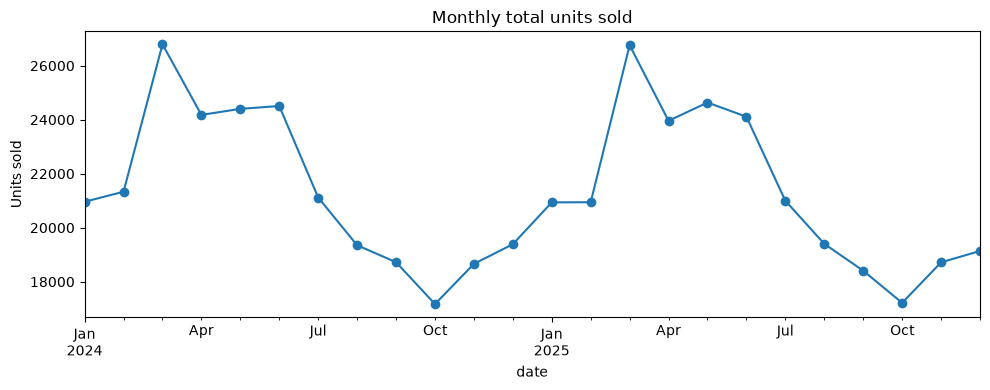

In [2]:

monthly = df.groupby(df['date'].dt.to_period('M'))['units_sold'].sum()
monthly.plot(kind='line', figsize=(10, 4), title='Monthly total units sold', marker='o')
plt.ylabel('Units sold')
plt.tight_layout()
plt.show()

In [3]:
# Cell 3 - top movers vs dead stock
by_sku = df.groupby(['sku_id', 'product_name', 'category'])['units_sold'].sum().sort_values(ascending=False)
print("Top 5 movers:\n", by_sku.head(5))
print("\nBottom 5 (dead stock candidates):\n", by_sku.tail(5))

Top 5 movers:
 sku_id  product_name  category  
SKU012  Product 012   Home Decor    19067
SKU045  Product 045   Storage       18612
SKU018  Product 018   Kitchen       18450
SKU049  Product 049   Lighting      18373
SKU037  Product 037   Home Decor    18155
Name: units_sold, dtype: int64

Bottom 5 (dead stock candidates):
 sku_id  product_name  category 
SKU004  Product 004   Lighting     3380
SKU015  Product 015   Storage      2994
SKU039  Product 039   Lighting     2300
SKU025  Product 025   Storage      1976
SKU011  Product 011   Furniture    1951
Name: units_sold, dtype: int64


In [4]:
# Cell 4 - category performance
cat = df.groupby('category').agg(
    total_units=('units_sold', 'sum'),
    total_revenue=('revenue', 'sum'),
    n_skus=('sku_id', 'nunique')
).sort_values('total_revenue', ascending=False)
cat

,total_units,total_revenue,n_skus
category,,,
Home Decor,132570,8.884681e+08,10
Furniture,82298,6.033905e+08,10
Storage,93367,5.819274e+08,10
Kitchen,101144,5.635346e+08,10
Lighting,102431,4.587362e+08,10


In [5]:
# Cell 5 - promo / holiday / weekend effects
print("Promo effect (avg daily units):\n", df.groupby('promo_flag')['units_sold'].mean())
print("\nHoliday effect:\n", df.groupby('is_holiday')['units_sold'].mean())
print("\nWeekend effect:\n", df.groupby('is_weekend')['units_sold'].mean())

Promo effect (avg daily units):
 promo_flag
0    13.475945
1    18.613067
Name: units_sold, dtype: float64

Holiday effect:
 is_holiday
0    14.023402
1    12.160000
Name: units_sold, dtype: float64

Weekend effect:
 is_weekend
0    13.077744
1    16.329519
Name: units_sold, dtype: float64


In [6]:
# Cell 6 - price vs demand correlation
print("Correlation (price, units_sold):", df['unit_price'].corr(df['units_sold']))

Correlation (price, units_sold): 0.082494966634164
